# **Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
df.dropna(inplace=True)


In [ ]:
df['sentiment'] = df['sentiment'].map({
    'negative':0,
    'positive':1
})

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['review'] = df['review'].apply(clean_text)

In [ ]:
df = df.sample(n=5000, random_state=42)

print(df.shape)

(5000, 2)


# **Data Splitting**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.30,
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    random_state=42
)

# **Tokenization**

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

# **Model Evaluation**

## **Create Dataset Class**

In [ ]:
import torch
class IMDbDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item['labels'] = torch.tensor(
            self.labels.iloc[idx]
        )

        return item

    def __len__(self):
        return len(self.labels)

# **Load Pretrained BERT**

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# **Training Arguments**

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=50
)

In [ ]:
import torch

print(torch.cuda.is_available())

True


In [ ]:
!pip install transformers==4.45.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 65.3 MB/s eta 0:00:00


In [ ]:
import transformers
print(transformers.__version__)

5.10.1


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_dir="./logs",
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# **Metrics Function**

In [ ]:
def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    accuracy = accuracy_score(
        labels,
        preds
    )

    precision = precision_score(
        labels,
        preds
    )

    recall = recall_score(
        labels,
        preds
    )

    f1 = f1_score(
        labels,
        preds
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# **Trainer**

In [ ]:
import torch

class IMDbDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels.iloc[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = IMDbDataset(
    train_encodings,
    train_labels
)

val_dataset = IMDbDataset(
    val_encodings,
    val_labels
)

test_dataset = IMDbDataset(
    test_encodings,
    test_labels
)

In [ ]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

3500
750
750


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.460861,0.901333,0.912329,0.888000,0.900000
2,0.233622,0.532976,0.896000,0.902439,0.888000,0.895161


Epoch,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=876, training_loss=0.17679142189896815, metrics={'train_runtime': 368.7789, 'train_samples_per_second': 18.982, 'train_steps_per_second': 2.375, 'total_flos': 1381333040640000.0, 'train_loss': 0.17679142189896815, 'epoch': 2.0})

# **Evaluate**

In [ ]:
results = trainer.evaluate(
    test_dataset
)

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.233622,0.530549,2,0.896000,0.886486,0.901099,0.893733


{'eval_loss': 0.5305489301681519, 'eval_accuracy': 0.896, 'eval_precision': 0.8864864864864865, 'eval_recall': 0.9010989010989011, 'eval_f1': 0.8937329700272479}


# **Confusion Matrix**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

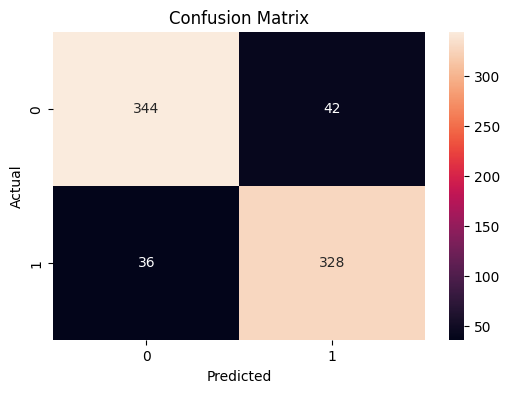

In [ ]:
predictions = trainer.predict(
    test_dataset
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

cm = confusion_matrix(
    test_labels,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **Freeze BERT Layers**

In [ ]:
from transformers import AutoModelForSequenceClassification

model_freeze = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

# Freeze all BERT layers
for param in model_freeze.bert.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer_freeze = Trainer(
    model=model_freeze,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer_freeze.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.686232,0.562667,0.543119,0.789333,0.643478
2,0.692299,0.685930,0.550667,0.530449,0.882667,0.662663


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=876, training_loss=0.6911668472638414, metrics={'train_runtime': 149.8329, 'train_samples_per_second': 46.719, 'train_steps_per_second': 5.847, 'total_flos': 920888693760000.0, 'train_loss': 0.6911668472638414, 'epoch': 2.0})

In [ ]:
freeze_results = trainer_freeze.evaluate(test_dataset)

print(freeze_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.692299,0.687594,2,0.545333,0.518400,0.890110,0.655207


{'eval_loss': 0.687594473361969, 'eval_accuracy': 0.5453333333333333, 'eval_precision': 0.5184, 'eval_recall': 0.8901098901098901, 'eval_f1': 0.6552072800808898}


In [ ]:
freeze_acc = freeze_results["eval_accuracy"]
freeze_prec = freeze_results["eval_precision"]
freeze_rec = freeze_results["eval_recall"]
freeze_f1 = freeze_results["eval_f1"]

# **Fine-Tune Last 2 Layers**

In [ ]:
model_last2 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

# Freeze all layers
for param in model_last2.bert.parameters():
    param.requires_grad = False

# Unfreeze last 2 encoder layers
for param in model_last2.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer_last2 = Trainer(
    model=model_last2,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer_last2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.304203,0.884000,0.875000,0.896000,0.885375
2,0.439940,0.311259,0.889333,0.886243,0.893333,0.889774


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=876, training_loss=0.37175056596869205, metrics={'train_runtime': 184.2773, 'train_samples_per_second': 37.986, 'train_steps_per_second': 4.754, 'total_flos': 920888693760000.0, 'train_loss': 0.37175056596869205, 'epoch': 2.0})

In [ ]:
last2_results = trainer_last2.evaluate(test_dataset)

print(last2_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.439940,0.353726,2,0.876000,0.867209,0.879121,0.873124


{'eval_loss': 0.3537260890007019, 'eval_accuracy': 0.876, 'eval_precision': 0.8672086720867209, 'eval_recall': 0.8791208791208791, 'eval_f1': 0.8731241473396999}


In [ ]:
last2_acc = last2_results["eval_accuracy"]
last2_prec = last2_results["eval_precision"]
last2_rec = last2_results["eval_recall"]
last2_f1 = last2_results["eval_f1"]

# **Full Fine-Tuning Metrics**

In [ ]:
full_results = trainer.evaluate(test_dataset)

print(full_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.233622,0.530549,2,0.896000,0.886486,0.901099,0.893733


{'eval_loss': 0.5305489301681519, 'eval_accuracy': 0.896, 'eval_precision': 0.8864864864864865, 'eval_recall': 0.9010989010989011, 'eval_f1': 0.8937329700272479}


In [ ]:
full_acc = full_results["eval_accuracy"]
full_prec = full_results["eval_precision"]
full_rec = full_results["eval_recall"]
full_f1 = full_results["eval_f1"]

# **Comparison Table**

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Experiment": [
        "Frozen BERT",
        "Last 2 Layers",
        "Full Fine-Tuning"
    ],
    "Accuracy": [
        freeze_acc,
        last2_acc,
        full_acc
    ],
    "Precision": [
        freeze_prec,
        last2_prec,
        full_prec
    ],
    "Recall": [
        freeze_rec,
        last2_rec,
        full_rec
    ],
    "F1 Score": [
        freeze_f1,
        last2_f1,
        full_f1
    ]
})

comparison

,Experiment,Accuracy,Precision,Recall,F1 Score
0,Frozen BERT,0.545333,0.518400,0.890110,0.655207
1,Last 2 Layers,0.876000,0.867209,0.879121,0.873124
2,Full Fine-Tuning,0.896000,0.886486,0.901099,0.893733


# **Save Table**

In [ ]:
comparison.to_csv(
    "experiment_comparison.csv",
    index=False
)

# **Accuracy Comparison Graph**

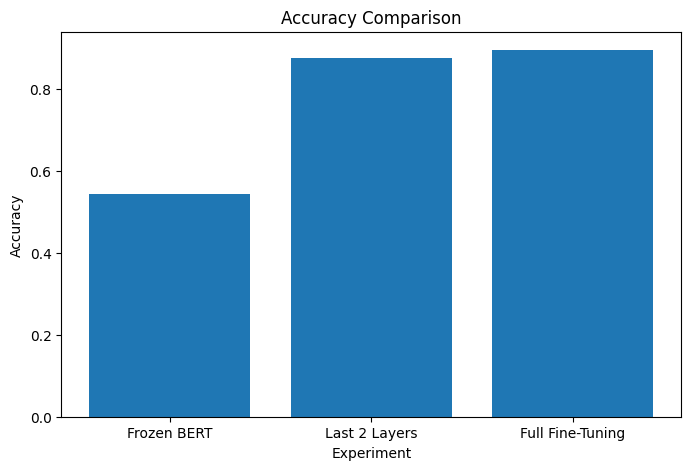

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Experiment"],
    comparison["Accuracy"]
)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Experiment")

plt.show()

## **F1 Score Comparison Graph**

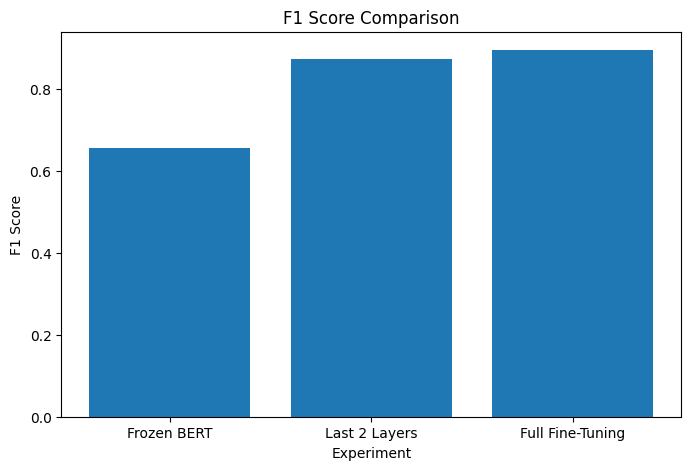

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Experiment"],
    comparison["F1 Score"]
)

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("Experiment")

plt.show()

In [ ]:
b